=== Training Collaborative Filtering ===
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4928 - loss: 0.6932 - val_accuracy: 0.5138 - val_loss: 0.6931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7347 - loss: 0.6876 - val_accuracy: 0.5144 - val_loss: 0.6931
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8637 - loss: 0.6782 - val_accuracy: 0.5069 - val_loss: 0.6931
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9422 - loss: 0.6613 - val_accuracy: 0.5119 - val_loss: 0.6933
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9758 - loss: 0.6325 - val_accuracy: 0.5113 - val_loss: 0.6937
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9864 - loss: 0.5874 - val_accuracy: 0.5094 - val_loss: 0.6951
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9917 - loss: 0.5251 - val_accuracy: 0.5075 - val_loss: 0.6978
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4703 - loss: 0.6957 - val_accuracy: 0.5750 - val_loss: 0.6904
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5922 - loss: 0.6850 - val_accuracy: 0.5813 - val_loss: 0.6835
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5828 - loss: 0.6753 - val_accuracy: 0.5688 - val_loss: 0.6839
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6078 - loss: 0.6631 - val_accuracy: 0.5500 - val_loss: 0.6793
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6313 - loss: 0.6406 - val_accuracy: 0.5437 - val_loss: 0.6985
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6703 - loss: 0.6117 - val_accuracy: 0.5188 - val_loss: 0.7169
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7031 - loss: 0.5839 - val_accuracy: 0.5063 - val_loss: 0.7537
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7453 - loss: 0.5374 - val_accuracy: 0.4750 - val_loss: 0.8191
Ep

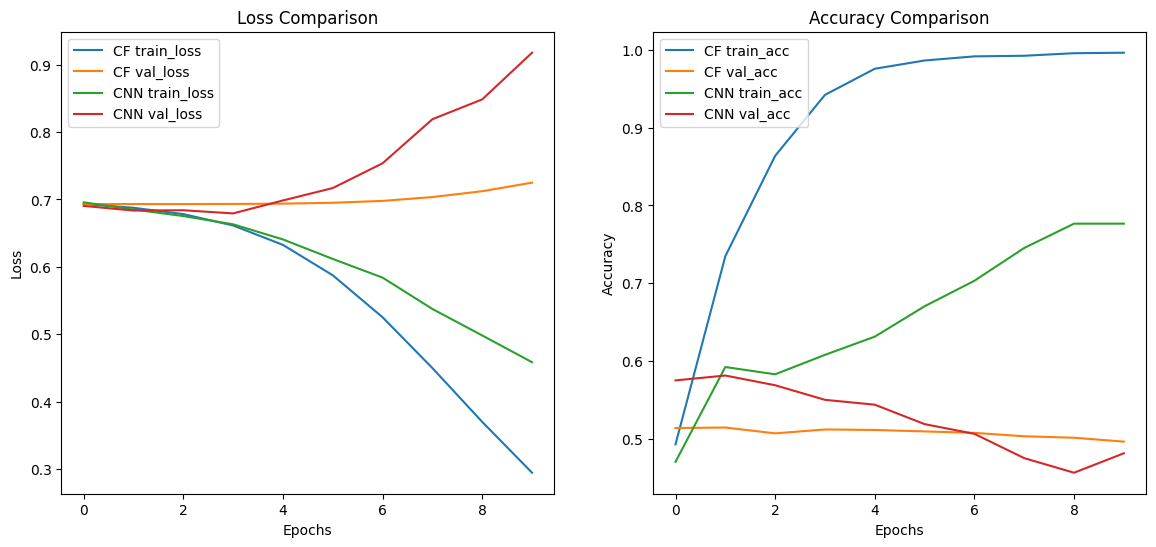

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# ==== 1. Generate synthetic dataset ====
num_users = 1000
num_items = 500
embedding_dim = 32
# Dataset dạng (user_id, item_id, rating)
user_ids = np.random.randint(0, num_users, size=10000)
item_ids = np.random.randint(0, num_items, size=10000)
ratings = np.random.randint(0, 2, size=10000)  # binary rating
X_train_user, X_test_user, X_train_item, X_test_item, y_train, y_test = train_test_split(
    user_ids, item_ids, ratings, test_size=0.2, random_state=42
)
train_inputs = np.stack([X_train_user, X_train_item], axis=1)
test_inputs = np.stack([X_test_user, X_test_item], axis=1)
# ==== 2. Collaborative Filtering Model ====
class CFModel(Model):
    def __init__(self, num_users, num_items, embedding_dim):
        super(CFModel, self).__init__()
        self.user_embedding = layers.Embedding(num_users, embedding_dim, embeddings_initializer="he_normal")
        self.item_embedding = layers.Embedding(num_items, embedding_dim, embeddings_initializer="he_normal")
        self.dot = layers.Dot(axes=1)
        self.out = layers.Dense(1, activation="sigmoid")
    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:,0])
        item_vector = self.item_embedding(inputs[:,1])
        x = self.dot([user_vector, item_vector])
        return self.out(x)
cf_model = CFModel(num_users, num_items, embedding_dim)
cf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
print("=== Training Collaborative Filtering ===")
cf_history = cf_model.fit(train_inputs, y_train, 
                          validation_split=0.2, 
                          epochs=10, batch_size=64, verbose=1)
cf_loss, cf_acc = cf_model.evaluate(test_inputs, y_test, verbose=0)
# ==== 3. CNN Model ====
# Biểu diễn mỗi user thành vector binary rating cho item (giả lập)
user_item_matrix = np.zeros((num_users, num_items))
for u, i, r in zip(user_ids, item_ids, ratings):
    user_item_matrix[u, i] = r
X = user_item_matrix.reshape((num_users, 20, 25, 1))  # reshape thành 20x25 "ảnh"
y = np.random.randint(0, 2, size=num_users)  # nhãn giả lập: sở thích tổng thể
X_train, X_test, y_train_cnn, y_test_cnn = train_test_split(X, y, test_size=0.2, random_state=42)
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(20,25,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\n=== Training CNN ===")
cnn_history = cnn_model.fit(X_train, y_train_cnn, 
                            validation_split=0.2,
                            epochs=10, batch_size=32, verbose=1)
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test_cnn, verbose=0)
# ==== 4. Compare Results ====
print(f"\n--- Final Results ---")
print(f"Collaborative Filtering - Loss: {cf_loss:.4f}, Accuracy: {cf_acc:.4f}")
print(f"CNN                    - Loss: {cnn_loss:.4f}, Accuracy: {cnn_acc:.4f}")
# ==== 5. Visualization ====
plt.figure(figsize=(14,6))
# Loss
plt.subplot(1,2,1)
plt.plot(cf_history.history['loss'], label='CF train_loss')
plt.plot(cf_history.history['val_loss'], label='CF val_loss')
plt.plot(cnn_history.history['loss'], label='CNN train_loss')
plt.plot(cnn_history.history['val_loss'], label='CNN val_loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Comparison")
# Accuracy
plt.subplot(1,2,2)
plt.plot(cf_history.history['accuracy'], label='CF train_acc')
plt.plot(cf_history.history['val_accuracy'], label='CF val_acc')
plt.plot(cnn_history.history['accuracy'], label='CNN train_acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN val_acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4982 - loss: 0.7070 - val_accuracy: 0.5031 - val_loss: 0.7052 - learning_rate: 0.0030
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5392 - loss: 0.7021 - val_accuracy: 0.5052 - val_loss: 0.7039 - learning_rate: 0.0030
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5865 - loss: 0.6882 - val_accuracy: 0.5042 - val_loss: 0.7230 - learning_rate: 0.0030
Epoch 4/40
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6016 - loss: 0.6809
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6180 - loss: 0.6657 - val_accuracy: 0.4948 - val_loss: 0.7479 - learning_rate: 0.0030
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6549 - loss: 0.6399 - val_accuracy: 0.4906 - val_loss: 0.7772 - learning_rate: 0.0015
Epoch 6/40
 1/30 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5938 - loss: 0.7018
Epoch 6: ReduceL

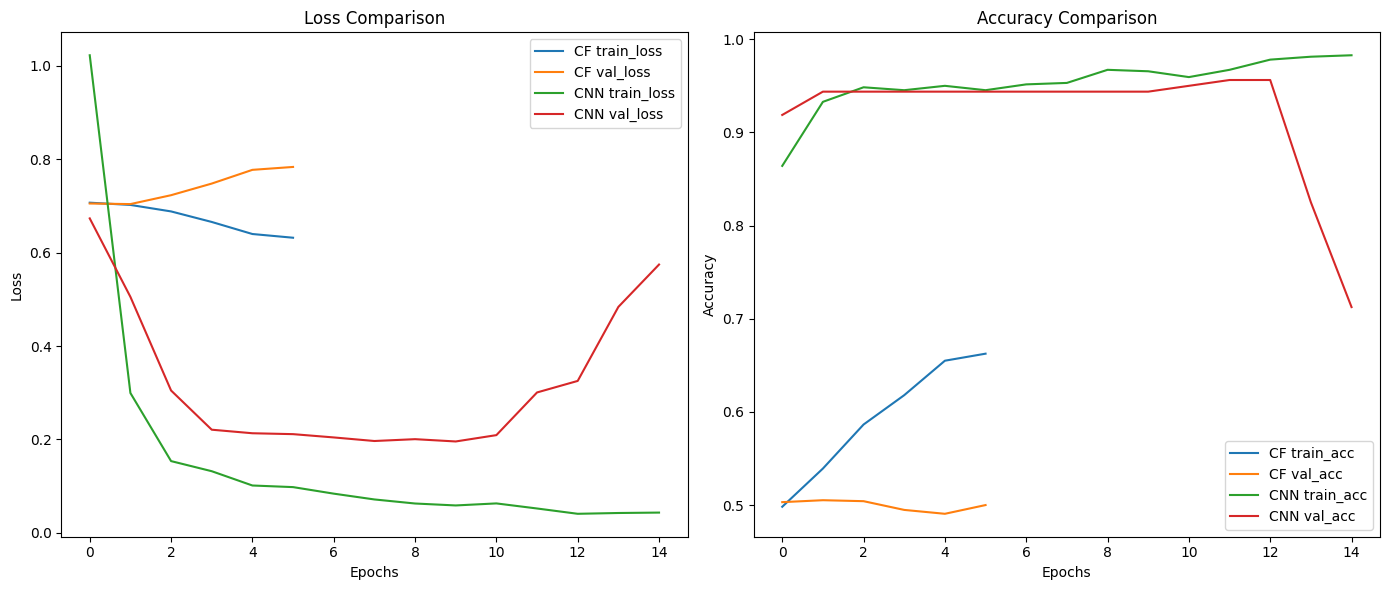


--- Final Results ---
Collaborative Filtering - Loss: 0.7044, Accuracy: 0.5108
CNN                    - Loss: 0.1848, Accuracy: 0.9500


In [4]:
# Đỗ Ngọc Lâm – B22DCCN476
import numpy as np, random, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers, Model
from sklearn.model_selection import train_test_split

# ====== 0. Reproducibility ======
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ====== 1. Synthetic dataset (user, item, rating) ======
num_users, num_items, embedding_dim = 1000, 500, 16
num_samples = 12000
user_ids = np.random.randint(0, num_users, size=num_samples)
item_ids = np.random.randint(0, num_items, size=num_samples)
ratings  = np.random.randint(0, 2, size=num_samples).astype("float32")

u_train, u_test, i_train, i_test, y_train, y_test = train_test_split(
    user_ids, item_ids, ratings, test_size=0.2, random_state=SEED, stratify=ratings)
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    u_train, i_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)
train_inputs = np.stack([u_train, i_train], axis=1)
val_inputs   = np.stack([u_val,   i_val],   axis=1)
test_inputs  = np.stack([u_test,  i_test],  axis=1)

# ====== 2. CF Model (Neural CF) ======
def build_cf_model(num_users, num_items, embedding_dim=16, l2=1e-4, p_drop=0.4):
    u_in = layers.Input(shape=(), dtype=tf.int32, name="user_id")
    i_in = layers.Input(shape=(), dtype=tf.int32, name="item_id")
    u_emb = layers.Embedding(num_users, embedding_dim,
                             embeddings_initializer="he_normal",
                             embeddings_regularizer=regularizers.l2(l2))(u_in)
    i_emb = layers.Embedding(num_items, embedding_dim,
                             embeddings_initializer="he_normal",
                             embeddings_regularizer=regularizers.l2(l2))(i_in)
    u, v = layers.Flatten()(u_emb), layers.Flatten()(i_emb)
    x = layers.Concatenate()([u, v])
    x = layers.GaussianNoise(0.05)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(p_drop)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(p_drop)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model([u_in, i_in], out, name="NeuralCF")
    model.compile(optimizer=tf.keras.optimizers.Adam(3e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

cf_model = build_cf_model(num_users, num_items, embedding_dim)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                              restore_best_weights=True, verbose=1)
plateau    = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                  patience=2, min_lr=1e-5, verbose=1)

# DÙNG ĐÚNG TÊN INPUT: "user_id", "item_id"
cf_history = cf_model.fit(
    {"user_id": train_inputs[:,0], "item_id": train_inputs[:,1]}, y_train,
    validation_data=({"user_id": val_inputs[:,0], "item_id": val_inputs[:,1]}, y_val),
    epochs=40, batch_size=256, callbacks=[early_stop, plateau], verbose=1
)
cf_test_loss, cf_test_acc = cf_model.evaluate(
    {"user_id": test_inputs[:,0], "item_id": test_inputs[:,1]}, y_test, verbose=0
)

# ====== 3. CNN Model (User–Item matrix as image) ======
user_item_matrix = np.zeros((num_users, num_items), dtype="float32")
for u, i, r in zip(user_ids, item_ids, ratings): user_item_matrix[u, i] = r
X_all = user_item_matrix.reshape((num_users, 20, 25, 1))
# nhãn tổng quát rất thô (minh hoạ): tỉ lệ 1s > ngưỡng
y_all = (user_item_matrix.mean(axis=1) > 0.02).astype("float32")

X_train, X_test, y_train_cnn, y_test_cnn = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
X_train, X_val, y_train_cnn, y_val_cnn = train_test_split(
    X_train, y_train_cnn, test_size=0.2, random_state=SEED, stratify=y_train_cnn)

def build_cnn(input_shape=(20,25,1), l2=1e-4, p_drop=0.5):
    m = models.Sequential(name="CNN_UserItem")
    m.add(layers.Input(shape=input_shape))
    m.add(layers.GaussianNoise(0.03))
    m.add(layers.Conv2D(16, (3,3), padding="same", activation="relu",
                        kernel_regularizer=regularizers.l2(l2)))
    m.add(layers.BatchNormalization()); m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Conv2D(32, (3,3), padding="same", activation="relu",
                        kernel_regularizer=regularizers.l2(l2)))
    m.add(layers.BatchNormalization()); m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Flatten())
    m.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2)))
    m.add(layers.Dropout(p_drop))
    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

cnn_model = build_cnn()
early_stop_cnn = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                  restore_best_weights=True, verbose=1)
plateau_cnn    = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                      patience=2, min_lr=1e-5, verbose=1)

cnn_history = cnn_model.fit(
    X_train, y_train_cnn,
    validation_data=(X_val, y_val_cnn),
    epochs=50, batch_size=64, callbacks=[early_stop_cnn, plateau_cnn], verbose=1
)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test_cnn, verbose=0)

# ====== 4. Visualization ======
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(cf_history.history["loss"], label="CF train_loss")
plt.plot(cf_history.history["val_loss"], label="CF val_loss")
plt.plot(cnn_history.history["loss"], label="CNN train_loss")
plt.plot(cnn_history.history["val_loss"], label="CNN val_loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.title("Loss Comparison"); plt.legend()
plt.subplot(1,2,2)
plt.plot(cf_history.history["accuracy"], label="CF train_acc")
plt.plot(cf_history.history["val_accuracy"], label="CF val_acc")
plt.plot(cnn_history.history["accuracy"], label="CNN train_acc")
plt.plot(cnn_history.history["val_accuracy"], label="CNN val_acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.title("Accuracy Comparison"); plt.legend()
plt.tight_layout(); plt.show()

print("\n--- Final Results ---")
print(f"Collaborative Filtering - Loss: {cf_test_loss:.4f}, Accuracy: {cf_test_acc:.4f}")
print(f"CNN                    - Loss: {cnn_test_loss:.4f}, Accuracy: {cnn_test_acc:.4f}")
